## Bias-variance tradeoff

### Bias

- Inability of machine leaning algorithm to capture true relationship of data is called bias.
- Bias measures how far off, on average, a model’s predictions are from the ground truth values. High-bias models tend to make strong assumptions about the form of the data and cause underfitting. An overly simplistic model tends to have high bias and low variance—a model like this tends to have high training errors and high prediction errors.   

### Variance

- Difference in fit between training set and data set is called variance.
- Variance measures how much a model’s predictions change with different training datasets. High-variance models are sensitive to noise in the training data and cause overfitting. A model with complex architecture and more parameters tends to have high variance and low bias.

### Underfitting

- When model has high bias and low variance it has underfitted the data.

### Overfitting

- When model has low bias and high variance it has overfitted the data.

## Codes

In [147]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

x, y = make_classification(n_samples=100, n_features=3, n_classes=2, n_informative=3, n_redundant=0, random_state=42, weights=[0.4, 0.6])

<Axes: xlabel='feature1', ylabel='feature2'>

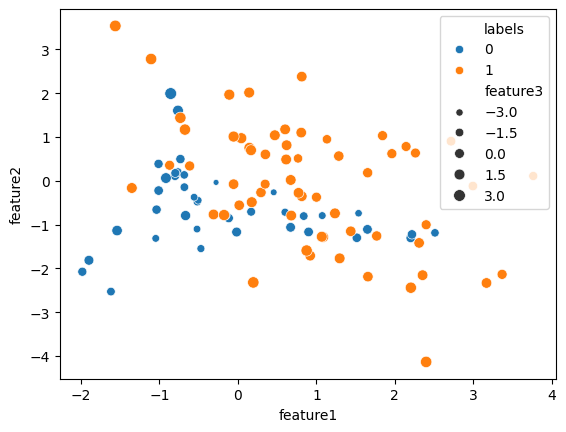

In [148]:
import seaborn as sns

df = pd.DataFrame({"feature1": x[:, 0], "feature2": x[:, 1], "feature3": x[:, 2], "labels": y})

sns.scatterplot(x=df["feature1"], y=df["feature2"], data=df, hue=df["labels"], size=df["feature3"])

In [149]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=72)

In [150]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [151]:
y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)

print(y_test)
print(y_pred_test)

[1 0 1 1 1 0 0 0 1 1 0 0 1 1 0 0 0 1 1 1]
[1 0 1 1 1 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1]


In [152]:
from sklearn.neighbors import KNeighborsRegressor

## Bias for Regression model

In [153]:
def bias_of_regression_models(x, y, k, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
        
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    return bias2

## Variance for Regression model

In [154]:
def variance_of_regression_models(x, y, k, n_rounds=100):
    
    model = KNeighborsRegressor(n_neighbors=k)
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,  random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return variance

## Bias–Variance tradeoff in KNN Classifier

In [155]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, n_informative=5, n_redundant=0, random_state=42, weights=[0.4, 0.6])

In [156]:
def bias_of_knn(x, y, k, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
        
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    return bias2

In [157]:
def variance_of_knn(x, y, k, n_rounds=100):
    
    model = KNeighborsRegressor(n_neighbors=k)
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,  random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return variance

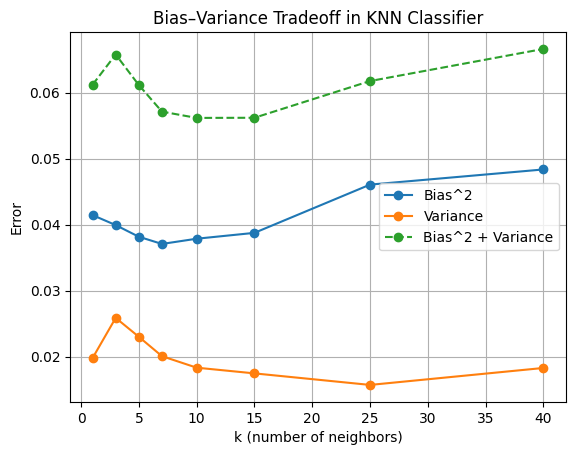

In [158]:
import matplotlib.pyplot as plt

ks = [1, 3, 5, 7, 10, 15, 25, 40]

biases = []
variances = []
total_error = []

for k in ks:
    
    b = bias_of_knn(x, y, k, n_rounds=200)
    v = variance_of_knn(x, y, k, n_rounds=200)
    
    biases.append(b)
    variances.append(v)
    total_error.append(b + v)

plt.plot(ks, biases, marker="o", label="Bias^2")
plt.plot(ks, variances, marker="o", label="Variance")
plt.plot(ks, total_error, marker="o", linestyle="--", label="Bias^2 + Variance")

plt.xlabel("k (number of neighbors)")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff in KNN Classifier")
plt.legend()
plt.grid(True)

## Bias–Variance tradeoff in Decision tree Regressor

In [159]:
from sklearn.datasets import make_regression

x, y = make_regression(n_samples=1000, n_features=3, n_informative=3, noise=0.1, random_state=42)   

In [160]:
from sklearn.tree import DecisionTreeRegressor

def bias_of_decision_tree(x, y, max_depth, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    avg_prediction = predictions.mean(axis=0)
    
    bias2 = np.mean((avg_prediction - y_test) ** 2)
    
    return bias2

In [161]:
def variance_of_decision_tree(x, y, max_depth, n_rounds=100):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    
    predictions = []
    
    for _ in range(n_rounds):
        
        idx = np.random.choice(len(x_train), len(x_train), replace=True)
        x_boot = x_train[idx]
        y_boot = y_train[idx]
        
        model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
        model.fit(x_boot, y_boot)
        
        predictions.append(model.predict(x_test))
        
    predictions = np.array(predictions)
    
    variance = np.mean(np.var(predictions, axis=0))
    
    return variance

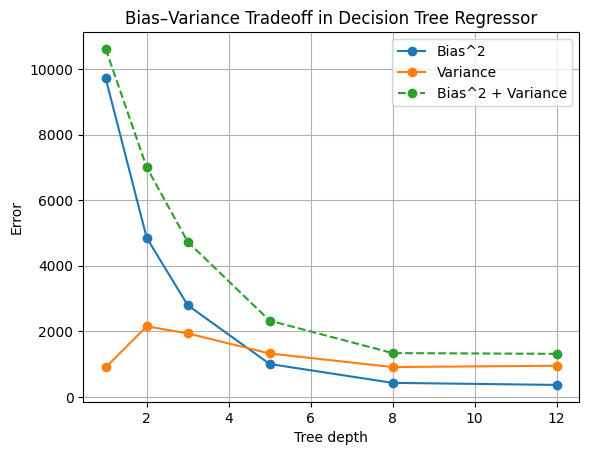

In [162]:
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 8, 12, None]

biases = []
variances = []
total_error = []

for depth in depths:
    
    b = bias_of_decision_tree(x, y, depth, 200)
    v = variance_of_decision_tree(x, y, depth, 200)
    
    biases.append(b)
    variances.append(v)
    total_error.append(b + v)
    

plt.plot(depths, biases, marker="o", label="Bias^2")
plt.plot(depths, variances, marker="o", label="Variance")
plt.plot(depths, total_error, marker="o", linestyle="--", label="Bias^2 + Variance")

plt.xlabel("Tree depth")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff in Decision Tree Regressor")
plt.legend()
plt.grid(True)